# PrimateFace Quick Start

| GitHub | Paper | Website | Models |
|---|---|---|---|
| [Code](https://github.com/KordingLab/PrimateFace) | [Preprint](https://www.biorxiv.org/content/10.1101/2025.08.12.669927) | [Project](https://primateface.studio/) | [HuggingFace](https://huggingface.co/fparodi/primateface-models) |

This notebook demonstrates the PrimateFace v2 API: detect primate faces, estimate 68-point facial landmarks, and extract analysis features — all in 3 lines of code.

**Requirements**: PrimateFace + MMDetection/MMPose + GPU (recommended)

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Ensure repo root is on path
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from notebook_utils import check_environment, setup_publication_style
setup_publication_style()
env_info = check_environment(require_packages=["mmdet", "mmpose"])

Publication plot style configured (Nature-style).


PrimateFace Environment
  Python:   3.11.11
  PyTorch:  2.1.2+cu118
  CUDA:     True
  Device:   cuda:0
  GPU:      NVIDIA GeForce RTX 4090 (25.8 GB)
  mmdet: 3.2.0 [OK]
  mmpose: 1.3.2 [OK]


## 2. Initialize PrimateFace

Models are automatically downloaded from [HuggingFace](https://huggingface.co/fparodi/primateface-models) on first use.

In [2]:
from primateface import PrimateFace

pf = PrimateFace()  # auto-downloads models, uses GPU if available
print(f"Device: {pf.device}")
print(f"Pose model: {pf.pose_model}")

Loads checkpoint by local backend from path: C:\Users\Felipe Parodi\.cache\huggingface\hub\models--fparodi--primateface-models\snapshots\4fade59531e3c11b77eacf26d741ef6746e09598\detection\cascade_rcnn_r101_fpn.pth


Loads checkpoint by local backend from path: C:\Users\Felipe Parodi\.cache\huggingface\hub\models--fparodi--primateface-models\snapshots\4fade59531e3c11b77eacf26d741ef6746e09598\pose\hrnetv2_w18_dark_68kpt.pth
Pose model loaded. Running detection + pose estimation.
Device: cuda:0
Pose model: hrnet


## 3. Analyze an Image

`.analyze()` runs face detection + 68-point landmark estimation and returns a list of `Face` objects.

In [3]:
# Use the bundled test image
image_path = str(REPO_ROOT / "demos" / "ateles_000003.jpeg")

faces = pf.analyze(image_path)
print(f"Detected {len(faces)} face(s)")
for face in faces:
    print(face)

Detected 1 face(s)
Face(score=1.00, bbox=[442, 228, 588, 415], landmarks=68)


## 4. Inspect a Face Object

Each `Face` has detection outputs (bbox, score, keypoints) and lazy analysis properties that are computed on first access.

In [4]:
face = faces[0]

# Detection outputs (always available)
print(f"Bounding box: {face.bbox}")
print(f"Confidence:   {face.score:.3f}")
print(f"Keypoints:    shape {face.keypoints.shape}  (68 landmarks x [x, y, score])")
print()

# Face crop
print(f"Crop shape:   {face.crop.shape}")

Bounding box: [442.4865  228.07495 588.74866 415.62082]
Confidence:   0.999
Keypoints:    shape (68, 3)  (68 landmarks x [x, y, score])

Crop shape:   (187, 146, 3)


## 5. Analysis Features (Lazy Evaluation)

These are computed from landmarks on first access — no additional models needed.

In [5]:
# Head pose (yaw, pitch, roll in degrees)
yaw, pitch, roll = face.head_pose
print(f"Head pose: yaw={yaw:.1f}, pitch={pitch:.1f}, roll={roll:.1f}")

# Facial symmetry (0 = perfect, higher = more asymmetric)
print(f"Symmetry (FA): {face.symmetry:.4f}")

# Kinematic features (~14 geometric measurements, normalized by IOD)
kin = face.kinematics
print(f"\nKinematic features ({len(kin)} total):")
for key, val in kin.items():
    print(f"  {key}: {val:.4f}")

# Shortcut properties
print(f"\nMouth aperture: {face.mouth_aperture:.4f}")
print(f"Eye aperture (R, L): {face.eye_aperture}")
print(f"Brow position (R, L): {face.brow_position}")
print(f"IOD (pixels): {face.interocular_distance:.1f}")

Head pose: yaw=14.4, pitch=55.3, roll=28.2
Symmetry (FA): 0.0098

Kinematic features (14 total):
  mouth_aperture: 0.2028
  mouth_width: 0.7907
  mouth_aspect_ratio: 0.2564
  right_eye_aperture: 0.1625
  left_eye_aperture: 0.1600
  right_brow_height: 0.3816
  left_brow_height: 0.3657
  face_height: 1.8431
  face_width: 2.1760
  face_aspect_ratio: 0.8470
  jaw_width: 1.7091
  nose_length: 0.4195
  eye_to_mouth: 1.1817
  interocular_distance: 66.1542

Mouth aperture: 0.2028
Eye aperture (R, L): (0.16251765952097577, 0.16003605713784863)
Brow position (R, L): (0.38156472870362684, 0.3657279009475306)
IOD (pixels): 66.2


In [6]:
# Face quality metrics
q = face.quality
print("Quality metrics:")
for key, val in q.items():
    print(f"  {key}: {val:.3f}")

# Per-region symmetry
rs = face.region_symmetry
print(f"\nRegion symmetry:")
for key, val in rs.items():
    print(f"  {key}: {val:.4f}")

Quality metrics:
  blur: 611.632
  size: 0.030
  visibility: 1.000
  brightness: 40.332
  score: 0.782

Region symmetry:
  jaw: 0.0119
  eyebrows: 0.0102
  eyes: 0.0083
  nose: 0.0088
  mouth: 0.0090


## 6. Visualization

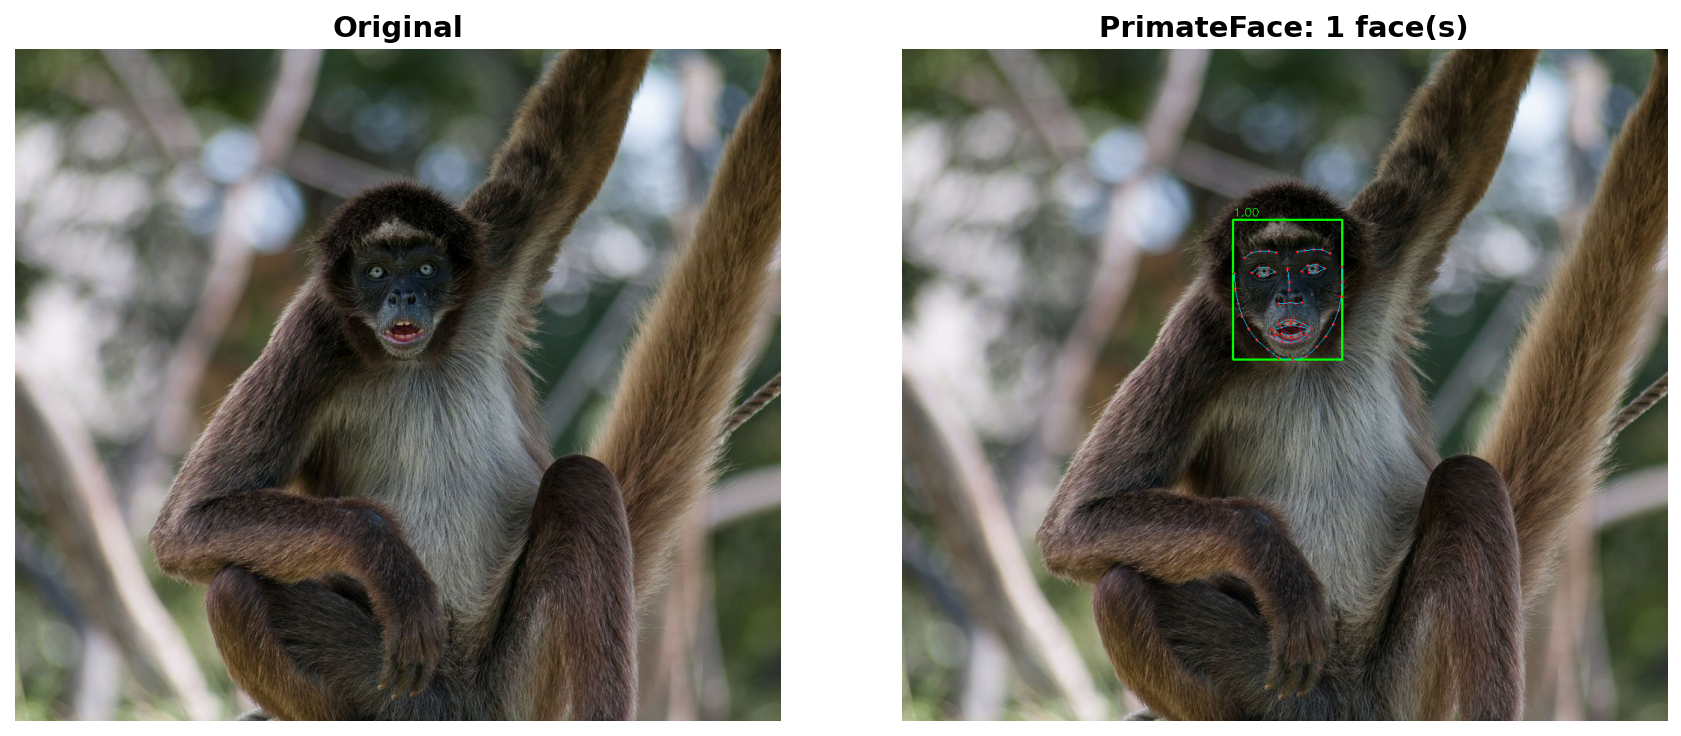

In [7]:
import matplotlib.pyplot as plt
import cv2

# Draw detections + landmarks on the image
viz = PrimateFace.draw(faces, image_path)

# Display (convert BGR -> RGB for matplotlib)
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

original = cv2.imread(image_path)
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"PrimateFace: {len(faces)} face(s)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 7. Export Results

Use `primateface.io` to save results in common formats.

In [8]:
from primateface.io import to_csv, to_coco_json

# Export to CSV (one row per face, all features)
to_csv(faces, "quickstart_results.csv", image_path=image_path)
print("Saved quickstart_results.csv")

# Export to COCO JSON
to_coco_json(faces, "quickstart_results.json", image_path=image_path)
print("Saved quickstart_results.json")

Saved quickstart_results.csv
Saved quickstart_results.json


In [9]:
# Preview the CSV
import pandas as pd
df = pd.read_csv("quickstart_results.csv")
print(f"CSV shape: {df.shape}")
df.head()

CSV shape: (1, 239)


,face_idx,score,bbox_x1,bbox_y1,bbox_x2,bbox_y2,image,kpt_0_x,kpt_0_y,kpt_0_score,...,quality_size,quality_visibility,quality_brightness,quality_score,symmetry_fa,symmetry_jaw,symmetry_eyebrows,symmetry_eyes,symmetry_nose,symmetry_mouth
0,0,0.998837,442.4865,228.07495,588.74866,415.62082,A:\NonEnclosureProjects\inprep\PrimateFace\pri...,444.778656,300.592621,0.856631,...,0.029658,1.0,40.332064,0.781896,0.009837,0.011867,0.010247,0.008259,0.008782,0.009


## 8. Pose Model Selection

PrimateFace supports multiple pose backends. The default `hrnet` is fast and lightweight (38 MB). For higher accuracy, use `vitpose` (1.2 GB).

In [10]:
# To use ViTPose instead (downloads on first use):
# pf_vit = PrimateFace(pose_model="vitpose")
# faces_vit = pf_vit.analyze(image_path)

print("Available pose models: hrnet (default, 38 MB), vitpose (1.2 GB)")

Available pose models: hrnet (default, 38 MB), vitpose (1.2 GB)


## Summary

PrimateFace v2 provides:
- **3-line API**: `PrimateFace()` → `.analyze()` → `Face` objects
- **Auto model download** from HuggingFace Hub
- **68-point landmarks** with lazy analysis (head pose, symmetry, kinematics, quality)
- **Visualization** via `PrimateFace.draw()`
- **Export** to CSV, COCO JSON, and more via `primateface.io`
- **CLI**: `primateface analyze image.jpg`

See the other tutorials for in-depth applications:
- [Lemur Video Timestamping](lemur_video_timestamping.ipynb)
- [Macaque Face Recognition](macaque_face_recognition.ipynb)
- [Howler Vocal-Motor Coupling](howler_vocal_motor_coupling.ipynb)
- [Infant Gaze Following](infant_gaze_following.ipynb)
- [Landmark-Based Demographics](landmark_demographics.ipynb)

## Citation

If you use PrimateFace in your research, please cite:

```bibtex
@article{parodi2025primateface,
  title   = {PrimateFace: a large-scale cross-species face image resource for primatology research},
  author  = {Parodi, Felipe and Weilong, Zhu and Bhatt, Aakash and Kording, Konrad},
  journal = {bioRxiv},
  year    = {2025},
  doi     = {10.1101/2025.08.12.669927}
}
```